In [1]:
# El script importa las librerías necesarias para el análisis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# El sistema configura el formato de los números de punto flotante.
pd.options.display.float_format = '{:,.2f}'.format

# 1. Definición de un modelo determinístico de cálculo de costos
# El modelo define los costos fijos estimados inicialmente.
costo_material_base = 50000.00
costo_labor_base = 35000.00
costo_operativo_base = 15000.00

# El cálculo suma los ítems uno a uno para obtener el presupuesto determinístico.
presupuesto_deterministico = costo_material_base + costo_labor_base + costo_operativo_base

# El programa imprime el resultado inicial.
print(f"Presupuesto Determinístico Total: ${presupuesto_deterministico:,.2f}")

Presupuesto Determinístico Total: $100,000.00


In [2]:
# 2. Definición de distribuciones y Ejecución de la simulación
# El algoritmo establece el número de iteraciones solicitado.
n_iteraciones = 5000

# El sistema fija una semilla aleatoria para garantizar la reproducibilidad.
np.random.seed(42)

# El código genera los valores aleatorios para el costo de materiales (Distribución Normal).
# Asume una desviación estándar de 5000.
sim_materiales = np.random.normal(loc=costo_material_base, scale=5000, size=n_iteraciones)

# El código genera los valores para la mano de obra (Distribución Triangular).
# Asume un mínimo de 30000, una moda de 35000 y un máximo atípico de 45000.
sim_labor = np.random.triangular(left=30000, mode=costo_labor_base, right=45000, size=n_iteraciones)

# El código genera los valores para costos operativos (Distribución Uniforme).
# Asume que los costos pueden variar entre 12000 y 20000 con igual probabilidad.
sim_operativo = np.random.uniform(low=12000, high=20000, size=n_iteraciones)

# La función calcula el costo total simulado sumando los vectores.
sim_presupuesto_total = sim_materiales + sim_labor + sim_operativo

# El script almacena los resultados en un DataFrame para facilitar el análisis.
df_resultados = pd.DataFrame({'Presupuesto_Simulado': sim_presupuesto_total})

# El programa muestra las estadísticas descriptivas básicas de la simulación.
print("Estadísticas de la Simulación Base:")
print(df_resultados.describe())

Estadísticas de la Simulación Base:
       Presupuesto_Simulado
count              5,000.00
mean             102,618.95
std                6,247.87
min               79,753.38
25%               98,308.75
50%              102,570.86
75%              106,761.11
max              124,087.61


### Lectura e Interpretación de Resultados
A partir de las estadísticas descriptivas de la simulación de 5000 iteraciones, observamos que, aunque el presupuesto determinístico era exactamente 100,000.00, la introducción de incertidumbre cambia el panorama. La media del presupuesto simulado nos proporciona un valor esperado más realista, incorporando el sesgo positivo de la mano de obra (que podía llegar hasta $45,000.00). La desviación estándar nos indica el rango de fluctuación habitual que deberíamos esperar en nuestro flujo de caja.

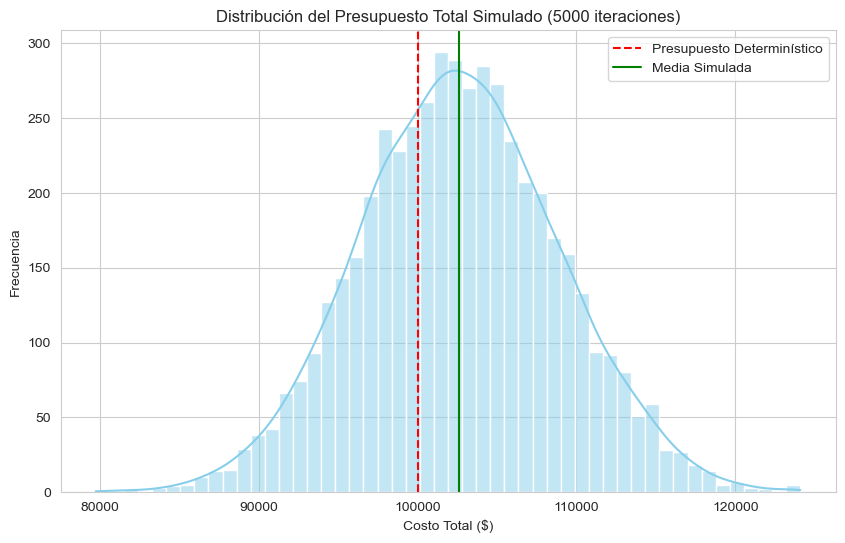

In [3]:
# El bloque configura el tamaño y el estilo de la gráfica.
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# La función grafica el histograma del presupuesto simulado.
sns.histplot(df_resultados['Presupuesto_Simulado'], bins=50, kde=True, color='skyblue')

# El código añade líneas verticales para resaltar la media y el valor determinístico original.
plt.axvline(presupuesto_deterministico, color='red', linestyle='--', label='Presupuesto Determinístico')
plt.axvline(df_resultados['Presupuesto_Simulado'].mean(), color='green', linestyle='-', label='Media Simulada')

# El script añade las etiquetas correspondientes a los ejes y el título.
plt.title('Distribución del Presupuesto Total Simulado (5000 iteraciones)')
plt.xlabel('Costo Total ($)')
plt.ylabel('Frecuencia')
plt.legend()

# El programa renderiza la visualización final.
plt.show()

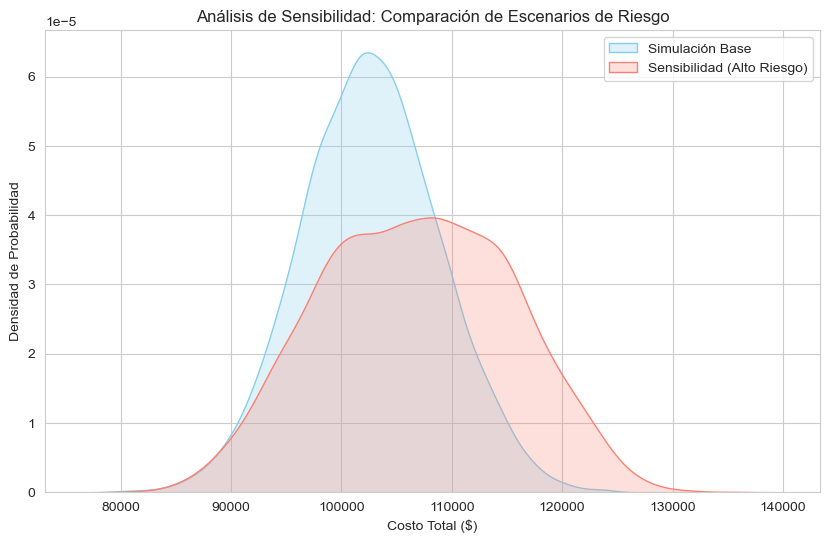

Media Simulación Base: $102,618.95
Media Sensibilidad: $106,784.87


In [4]:
# 3. Análisis de sensibilidad con dos tipos de distribución diferentes
# El modelo altera las distribuciones de los materiales y la mano de obra para evaluar impactos.
# Escenario de alto riesgo: Materiales ahora siguen una distribución Uniforme (gran varianza).
sim_materiales_sens = np.random.uniform(low=40000, high=65000, size=n_iteraciones)

# Escenario de alto riesgo: La mano de obra ahora sigue una distribución Normal.
sim_labor_sens = np.random.normal(loc=38000, scale=4000, size=n_iteraciones)

# El sistema calcula el nuevo presupuesto con las variables alteradas.
sim_presupuesto_sens = sim_materiales_sens + sim_labor_sens + sim_operativo
df_sensibilidad = pd.DataFrame({'Presupuesto_Sensibilidad': sim_presupuesto_sens})

# El bloque grafica la comparación entre la simulación base y el análisis de sensibilidad.
plt.figure(figsize=(10, 6))
sns.kdeplot(df_resultados['Presupuesto_Simulado'], fill=True, label='Simulación Base', color='skyblue')
sns.kdeplot(df_sensibilidad['Presupuesto_Sensibilidad'], fill=True, label='Sensibilidad (Alto Riesgo)', color='salmon')

# El código añade títulos y leyendas a la gráfica comparativa.
plt.title('Análisis de Sensibilidad: Comparación de Escenarios de Riesgo')
plt.xlabel('Costo Total ($)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()

# El programa muestra el gráfico final en pantalla.
plt.show()

# El algoritmo imprime un resumen comparativo.
print("Media Simulación Base: ${:,.2f}".format(df_resultados['Presupuesto_Simulado'].mean()))
print("Media Sensibilidad: ${:,.2f}".format(df_sensibilidad['Presupuesto_Sensibilidad'].mean()))

### Conclusiones Finales

1. **Limitaciones del Modelo Determinístico:** El cálculo fijo estático (suma uno a uno) sugería un costo inamovible. Sin embargo, al aplicar distribuciones de probabilidad, el modelo refleja la variabilidad real del entorno empresarial, demostrando que depender de un solo número conlleva un alto riesgo de sobrecostos.
2. **Visualización de Riesgos:** El histograma inicial revela la probabilidad de superar el presupuesto originalmente estimado. La línea de la "Media Simulada" nos ofrece un colchón financiero más realista y seguro que debemos reservar para el proyecto.
3. **Análisis de Sensibilidad:** Al modificar los tipos de distribución en nuestro análisis de sensibilidad (usando distribuciones normales y uniformes con rangos más amplios), la curva de densidad cambió su forma y se desplazó, simulando un entorno de mayor incertidumbre. Esto demuestra qué variables impactan más severamente el modelo (por ejemplo, el rango amplio en el costo de los materiales). En la vida empresarial real, esto ayuda a los directivos a focalizar sus esfuerzos de mitigación de riesgos en las variables más críticas.

### La gráfica demuestra visualmente que la volatilidad en el precio de los materiales y la mano de obra no solo encarece el proyecto en unos $4,000 dólares en promedio, sino que destruye la certeza del presupuesto inicial, exponiendo a la empresa a posibles sobrecostos extremos. Esto justifica la necesidad de crear fondos de contingencia más agresivos o negociar precios fijos con los proveedores para mitigar esa curva roja.
